<a href="https://colab.research.google.com/github/estebanhst/dinamica_estructural/blob/main/Porticos2D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
'''TRABAJO 2/3 DINÁMICA DE ESTRUCTURAS
Presentado por: Nelson Esteban Hernández Soto
Lunes 26 de septiembre de 2022
Próximamente se espera optimizar más este código e implementar más funciones
Ya se verificó respecto a los códigos de Juan Pablo
Es importante aclarar que la numeración de la matriz de masa y de rigidez es
primera fila/columna, piso 1 y así
'''
#%% INICIO
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sp


plt.style.use('ggplot')

def reducir_matriz(K, n_pisos):
   # Primero se reduce por las filas
   gdl = np.shape(K)[0]
   K_f = np.zeros((n_pisos, gdl))
   for i in range(n_pisos):
      for j in range(int(gdl/n_pisos)):
         K_f[i] += K[i+3*j]
   # Ahora se reduce por columnas
   K_r = np.zeros((n_pisos, n_pisos))
   for i in range(n_pisos):
      for j in range(int(gdl/n_pisos)):
         K_r[:,i] += K_f[:,i+3*j]
   return K_r

#%% CONSTANTES PARA MEJORAR LA LECTURA DEL CÓDIGO
NL1, NL2, TIPO = 0, 1, 2     # Nodo local 1, Nodo local 2
X, Y, TH       = 0, 1, 2     # TH = theta
b, h           = 0, 1        # b = base, h = altura

n_asignado = 7
g = 9.8 # m/s²
# Se asume que se tiene un edificio de concreto reforzado
fpc = 21 # MPa
E_c = 4700*np.sqrt(fpc)*1000  # [kN/m²]
n_pisos = 3
n_porticos = 4 # Número de pórticos en la dirección de análisis
h_entrepiso = 3.4
D_losa = 220+40*n_asignado  # kgf/m²
D_cub = D_losa/2            # kgf/m²
Lu_dirY = np.array([6,6])         # [m] Luces en dirección Y
Lu_dirX = np.array([6.5, 7, 6.5]) # [m] Luces en dirección X
LY = np.sum(Lu_dirY) # [m] Longitud total de la losa en dirección X
LX = np.sum(Lu_dirX) # [m] Longitud total de la losa en dirección Y
A_losa = LX*LY       # [m²]
DeltaMAX = 3.4    # [cm]
DeltaMAXmin = 3.3 # [cm]
# Dimensiones de los elementos del pórtico np.array([b, h])
COL = np.array([0.45, 0.5])
VIG = np.array([0.3, 0.4])

print(f'Propiedades mecánicas del material:\n\
   E= {E_c:.3f} kN/m²')
print(f'Cargas muertas del pórtico:\n\
   D Losa     = {D_losa} kgf/m²\n\
   D Cubierta = {D_cub} kgf/m²\n')

Propiedades mecánicas del material:
   E= 21538105.766 kN/m²
Cargas muertas del pórtico:
   D Losa     = 500 kgf/m²
   D Cubierta = 250.0 kgf/m²



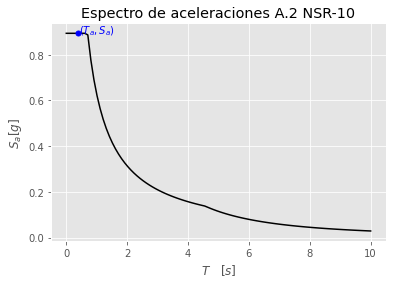

PERIODO Y ACELERACIÓN DE LA ESTRUCTURA: 
   T_a = 0.38005 s
   S_a = 0.89375(g)



In [ ]:
# Ciudad = Manizales, Grupo de uso = II, Suelo = D
Aa = 0.25   # A.2.3-2. Coeficiente de aceleración horizontal pico efectiva.
Av = 0.25   # A.2.3-2. Coeficiente de velocidad horizontal pico efectiva.
Fa = 1.3    # A.2.4-3. Coeficiente de amplificación de la aceleración para periodos cortos.
Fv = 1.9    # A.2.4-4. Coeficiente de amplificación de la aceleración en la zona de periodos intermedios.
Coef_I = 1.10   # A.2.5-1. Coeficiente de importancia.

# Parámetros dinámicos para una estructura con pórticos de concreto.
Ct    = 0.047  # A.2.5-1.  Coeficiente para el cálculo del periodo.
alfa  = 0.90   # A.2.5-1.  Exponente para el cálculo del periodo.

# Cálculo de periodos
T_a = Ct*(h_entrepiso*n_pisos)**alfa  # [s] Periodo fundamental aproximado, A.4.2-3.
T_0 = 0.1*(Av*Fv)/(Aa*Fa)   # [s] Periodo inicial.
T_C = 0.48*(Av*Fv)/(Aa*Fa)  # [s] Periodo corto.
T_L = 2.4*Fv                # [s] Periodo largo.        Figura A.2.6-1.

# Aceleración para el periodo fundamental aproximado.
if T_a < T_C:
   Sa = 2.5*Aa*Fa*Coef_I
elif T_a > T_L:
   Sa = 1.2*Av*Fv*T_L*Coef_I/T_a**2
else:
   Sa = 1.2*Av*Fv*Coef_I/T_a
# Valor del exponente k (minúscula)
if T_a <= 0.5:
   k = 1
elif T_a > 2.5:
   k = 2
else:
   k = 0.75+0.5*T_a

# Gráfica del espectro de aceleraciones
t_espectro = np.linspace(0, 10, 100)
sa_espectro = np.zeros_like(t_espectro)
for t,i in zip(t_espectro,range(len(t_espectro))):
   if t < T_C:
      sa_espectro[i] = 2.5*Aa*Fa*Coef_I
   elif t > T_L:
      sa_espectro[i] = 1.2*Av*Fv*T_L*Coef_I/t**2
   else:
      sa_espectro[i] = 1.2*Av*Fv*Coef_I/t

plt.figure()
plt.plot(t_espectro, sa_espectro, '-k')
plt.plot(T_a, Sa, '.b', ms=10)
plt.title('Espectro de aceleraciones A.2 NSR-10')
plt.xlabel(r'$T\quad [s]$')
plt.ylabel(r'$S_a[g]$')
plt.text(1.1*T_a, Sa, r"$(T_a,S_a)$", fontsize=10, color='b')
plt.grid(visible=True)
plt.show()
print(f'PERIODO Y ACELERACIÓN DE LA ESTRUCTURA: \n\
   T_a = {T_a:.5f} s\n\
   S_a = {Sa}(g)\n')

In [ ]:
#%% FUERZA HORIZONTAL EQUIVALENTE
masa_pisos = np.array([])
h_acumu = np.array([])
for i in range(1,n_pisos+1):
   h_acumu = np.append(h_acumu, i*h_entrepiso)
   if i < n_pisos:
      masa_pisos = np.append(masa_pisos, D_losa)
   else:
      masa_pisos = np.append(masa_pisos, D_cub)
masa_pisos = masa_pisos*A_losa*(g/1000)    # kN
masa_total = np.sum(masa_pisos)   # kN
Vs = masa_total*(Sa)     # kN
m_h_k = masa_pisos*(h_acumu**k) # kN
C_vx = m_h_k/np.sum(m_h_k)      # [%]
FHE_piso = Vs*C_vx              # kN
print(f'MÉTODO DE LA FUERZA HORIZONTAL EQUIVALENTE:\n\
(se desprecia la masa aportada por las vigas y columnas)\n\
   MASA TOTAL     = {masa_total:.3f} kN\n\
   CORTANTE BASAL = {Vs:.3f} kN')

MÉTODO DE LA FUERZA HORIZONTAL EQUIVALENTE:
(se desprecia la masa aportada por las vigas y columnas)
   MASA TOTAL     = 2940.000 kN
   CORTANTE BASAL = 2627.625 kN


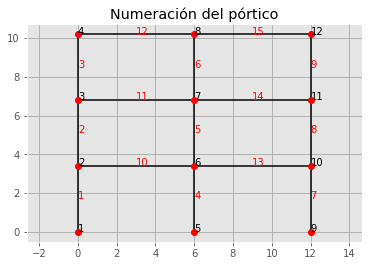

Sección columnas (b h): [0.45 0.5 ] 
Sección vigas (b h): [0.3 0.4]
MATRIZ DE RIGIDEZ CONDENSADA:
[[ 606703.134 -349028.403   84097.923]
 [-349028.403  417269.422 -180404.679]
 [  84097.923 -180404.679  113953.055]]

DESPLAZAMIENTOS [cm]:
[2.164 5.489 7.861]
DESPLAZAMIENTOS RELATIVOS [cm]:
[2.164 3.325 2.372]
CUMPLE
DERIVAS [%]:
[0.637 0.978 0.698]


In [ ]:
#%% Se define la estructura
xnod = np.array([[0, 0],   # coordenadas de cada nodo [x, y]
                 [0, 3.4],
                 [0, 6.8],
                 [0, 10.2],
                 [6, 0],
                 [6, 3.4],
                 [6, 6.8],
                 [6, 10.2],
                 [12, 0],
                 [12, 3.4],
                 [12, 6.8],
                 [12, 10.2]])

# LaG: local a global: matriz que relaciona nodos locales y globales
# fila = barra
# col1 = nodo global asociado a nodo local 1
# col2 = nodo global asociado a nodo local 2
# (se lee la barra x va del nodo i al nodo j)

#                  NL1   NL2  TIPO -> 1 COL, 2 VIG
barra = np.array([[1,    2,   1],
                  [2,    3,   1],
                  [3,    4,   1],
                  [5,    6,   1],
                  [6,    7,   1],
                  [7,    8,   1],
                  [9,   10,   1],
                  [10,  11,   1],
                  [11,  12,   1],
                  [2,    6,   2],
                  [3,    7,   2],
                  [4,    8,   2],
                  [6,   10,   2],
                  [7,   11,   2],
                  [8,   12,   2]])-1

LaG = barra[:, [NL1, NL2]]  # local a global
tipo = barra[:, TIPO]        # material - 1 columna - 2 viga
nno  = xnod.shape[0] # número de nodos (numero de filas de xnod)
nbar = LaG.shape[0]  # número de EFs (numero de filas de LaG)
ngdl = 3*nno         # número de grados de libertad (tres por nodo)

# coordenadas de los nodos de cada barra
x1 = np.zeros(nbar)
y1 = np.zeros(nbar)
x2 = np.zeros(nbar)
y2 = np.zeros(nbar)
for e in range(nbar):
    x1[e] = xnod[LaG[e,NL1], X];  x2[e] = xnod[LaG[e,NL2], X]
    y1[e] = xnod[LaG[e,NL1], Y];  y2[e] = xnod[LaG[e,NL2], Y]

#                  área       inercias_y       módulo de elasticidad
#                  A(m^2)        I(m^4)           E(kN/m^2)
props = np.array([[COL[b]*COL[h],   (COL[b]*COL[h]**3)/12,     E_c],
                  [VIG[b]*VIG[h],   (VIG[b]*VIG[h]**3)/12,     E_c]])

A = props[:,0];   I = props[:,1];   E = props[:,2]

#%% gdl: grados de libertad
# fila = nodo
# col1 = gdl en dirección x
# col2 = gdl en dirección y
# col3 = gdl en dirección angular antihoraria
gdl = np.arange(ngdl).reshape(nno, 3)  # nodos vs grados de libertad

#%% Ángulo, área y longitud por barra
area = np.zeros(nbar)
ang = np.zeros(nbar)
long = np.zeros(nbar)
for e in range(nbar):
   long[e] = np.hypot(x2[e]-x1[e], y2[e]-y1[e]) # m
   ang[e] = np.arctan2(y2[e]-y1[e], x2[e]-x1[e]) # radianes
   area[e] = A[barra[e,TIPO]]          # m3

#%% Se dibuja la estructura junto con su numeración
plt.figure(1)
for e in range(nbar):
   plt.plot(xnod[LaG[e,:],X], xnod[LaG[e,:],Y], 'k-')

   # Calculo la posición del centro de gravedad de la barra
   cgx = (xnod[LaG[e,NL1],X] + xnod[LaG[e,NL2],X])/2
   cgy = (xnod[LaG[e,NL1],Y] + xnod[LaG[e,NL2],Y])/2
   plt.text(cgx, cgy, str(e+1), color='red')

plt.plot(xnod[:,X], xnod[:,Y], 'ro')
for n in range(nno):
    plt.text(xnod[n,X], xnod[n,Y], str(n+1), color='k')

plt.axis('equal')
plt.grid(visible=True, which='both', color='0.65',linestyle='-')
plt.title('Numeración del pórtico')
plt.show()

#%% ensamblo la matriz de rigidez global
K   = np.zeros((ngdl,ngdl))  # separo memoria
Ke  = nbar*[None]
T   = nbar*[None]
idx = np.zeros((nbar,6), dtype=int)

for e in range(nbar): # para cada barra
   # saco los 6 gdls de la barra e
   idx[e] = np.r_[gdl[LaG[e,NL1],:], gdl[LaG[e,NL2],:]]

   L = long[e]

   # matriz de transformación de coordenadas para la barra e
   c = np.cos(ang[e]);   s = np.sin(ang[e])  # seno y coseno de la inclinación
   T[e] = np.array([[ c,  s,  0,  0,  0,  0],
                    [-s,  c,  0,  0,  0,  0],
                    [ 0,  0,  1,  0,  0,  0],
                    [ 0,  0,  0,  c,  s,  0],
                    [ 0,  0,  0, -s,  c,  0],
                    [ 0,  0,  0,  0,  0,  1]])

   # matriz de rigidez local expresada en el sistema de coordenadas locales
   # para la barra e
   AE = A[tipo[e]]*E[tipo[e]];       L2=L**2
   EI = E[tipo[e]]*I[tipo[e]];       L3=L**3
   Kloc = np.array([
        [ AE/L,   0      ,   0      ,  -AE/L,    0      ,   0      ],
        [ 0   ,  12*EI/L3,   6*EI/L2,   0   ,  -12*EI/L3,   6*EI/L2],
        [ 0   ,   6*EI/L2,   4*EI/L ,   0   ,   -6*EI/L2,   2*EI/L ],
        [-AE/L,   0      ,   0      ,   AE/L,    0      ,   0      ],
        [ 0   , -12*EI/L3,  -6*EI/L2,   0   ,   12*EI/L3,  -6*EI/L2],
        [ 0   ,   6*EI/L2,   2*EI/L ,   0   ,   -6*EI/L2,   4*EI/L ]])

   # matriz de rigidez local en coordenadas globales
   Ke[e] = T[e].T @ Kloc @ T[e]
   K[np.ix_(idx[e],idx[e])] += Ke[e] # ensambla Ke{e} en K global

#%% grados de libertad del desplazamiento conocidos (c) y desconocidos (d)
apoyos = np.array([[gdl[1-1,X],  0],
                   [gdl[1-1,Y],  0],
                   [gdl[1-1,TH], 0],
                   [gdl[5-1,X],  0],
                   [gdl[5-1,Y],  0],
                   [gdl[5-1,TH], 0],
                   [gdl[9-1,X],  0],
                   [gdl[9-1,Y],  0],
                   [gdl[9-1,TH], 0]])

c = apoyos[:,0].astype(int)
d = np.setdiff1d(np.arange(ngdl), c)
gdl_nc = np.setdiff1d(d, np.union1d(gdl[:,Y], gdl[:,TH]))
gdl_c = np.setdiff1d(d, gdl_nc)

K0 = K[ np.ix_( gdl_nc, gdl_nc )]
K1 = K[ np.ix_( gdl_nc, gdl_c ) ]
K2 = K[ np.ix_( gdl_c, gdl_nc ) ]
K3 = K[ np.ix_( gdl_c, gdl_c )  ]

K_condensada = (K0 - K1 @ np.linalg.inv(K3) @ K2)*n_porticos
# Ahora lo que resta es sumar los grados de libertad por cada piso para así reducir la matriz
# AQUÍ SE EVIDENCIA LA IMPORTANCIA DE NUMERAR EN ORDEN PRIMERO LAS COLUMNAS Y LUEGO LAS VIGAS
K_c = reducir_matriz(K_condensada, n_pisos) # kN/m
print('Sección columnas (b h):', COL,'\nSección vigas (b h):', VIG)
print('MATRIZ DE RIGIDEZ CONDENSADA:')
print(K_c.round(3))

# Traigo las fuerzas del método de la fuerza horizontal equivalente
# Cambio de unidades de kgf a kN
F = FHE_piso                    # [kN]
U = np.linalg.solve(K_c, F)*100 # [cm]

print('\nDESPLAZAMIENTOS [cm]:')
print(U.round(3))
U_rel = U-np.append(0,U[:-1])
derivas = U_rel/h_entrepiso
print('DESPLAZAMIENTOS RELATIVOS [cm]:')
print(U_rel.round(3))
if DeltaMAXmin < max(U_rel) < DeltaMAX:
   print("CUMPLE")
else:
   print("NO CUMPLE")
print('DERIVAS [%]:')
print(derivas.round(3))

In [ ]:
# %% SOLUCIÓN MODAL PARA EL CASO NO AMORTIGUADO
M = np.diag(masa_pisos/g) # kN*s²/m

# Variables simbólicas.
lam, ome, fi, alf = sp.symbols('lambda, omega, Phi, alpha')

# Polinomio caracterísitco.
# lam = ome^2
poli_car = sp.det(sp.Matrix(K_c - lam*M))

# Solución de los lambdas,
lams = np.sort(np.array([ float( sp.re( sp.solve( poli_car, lam )[0]) ),
                          float( sp.re( sp.solve( poli_car, lam )[1]) ),
                          float( sp.re( sp.solve( poli_car, lam )[2]) )]
                        ))

# Cálculo de vibraciones, frecuencias y periodos
wwi = np.sqrt(lams)  # [rad/s]   Vector de frecuencias angulares.
Tt  = 2*np.pi/wwi    # [s]       Vector de periodos de la estructura.
ff  = 1/Tt           # [Hz]      Vector de frecuencias.

# -----------------------------------------------------------------------------
print("\nVibraciones, frecuencias y periodos.")
print(f">>> {sp.pretty(lam)}: Soluciones {sp.pretty(lam)} del polinomio.")
print(f">>> {sp.pretty(ome)}: Frecuencias angulares {sp.pretty(ome)} de la edificación.")
print(">>> T: Periodos T de la edificación.")
print(">>> f: Frecuencias f de la edificación.\n")

tabla_vfp = pd.DataFrame(
    data = np.c_[lams.round(5), wwi.round(5), Tt.round(5), ff.round(5)],
    index = np.arange(n_pisos)+1,
    columns = [f"{sp.pretty(lam)}", f"{sp.pretty(ome)} [rad/s]", "T [s]", "f [Hz]"]
)
print(tabla_vfp)

# Periodo de Rayleigh
T_Rayleigh = 2*np.pi*np.sqrt(np.sum(M*(U/100)**2)/np.sum(F*(U/100)))
print(f'T Rayleigh = {T_Rayleigh:.5f} s')
# # %%

# MATRIZ MODAL
Phi = np.zeros((n_pisos, n_pisos))

for j in range(n_pisos):
   # Se calcula el vector de amplitudes del movimiento armónico
   Phi_j = np.linalg.eigh(K_c-lams[j]*M)[1][:,j]
   # Norma respecto a la masa
   r_j = Phi_j.T @ M @ Phi_j
   # Se agrega el vector normalizado en la matriz modal
   Phi[:,j] = Phi_j/np.sqrt(r_j)

print('MATRIZ MODAL')
print(Phi)
compr_lams = Phi.T @ K_c @ Phi
compr_Id = Phi.T @ M @ Phi
print('Comprobación frecuencias')
print(compr_lams.round(3))
print('Comprobación identidad')
print(compr_Id.round(3))

# PARTICIPACIÓN MODAL
alfa = Phi.T @ M @ np.ones((n_pisos,1))
M_mod_efectiva = alfa**2
participacion_masa = M_mod_efectiva/np.sum(M_mod_efectiva)
pctj_participacion = participacion_masa*100


print('Masa modal efectiva')
print(M_mod_efectiva.round(2))
print('Porcentaje de participación de masa')
print(pctj_participacion.round(2))


Vibraciones, frecuencias y periodos.
>>> λ: Soluciones λ del polinomio.
>>> ω: Frecuencias angulares ω de la edificación.
>>> T: Periodos T de la edificación.
>>> f: Frecuencias f de la edificación.

            λ  ω [rad/s]    T [s]    f [Hz]
1   184.60601   13.58698  0.46244   2.16243
2  2239.18324   47.32001  0.13278   7.53121
3  8008.53297   89.49041  0.07021  14.24284
T Rayleigh = 0.46241 s
MATRIZ MODAL
[[ 0.02415337  0.05893848  0.06539268]
 [ 0.06181162  0.03692919 -0.05611499]
 [ 0.08864843 -0.08361606  0.04262015]]
Comprobación frecuencias
[[ 184.606    0.       0.   ]
 [   0.    2239.183    0.   ]
 [   0.       0.    8008.533]]
Comprobación identidad
[[ 1. -0. -0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]
Masa modal efectiva
[[244.44]
 [ 42.08]
 [ 13.47]]
Porcentaje de participación de masa
[[81.48]
 [14.03]
 [ 4.49]]


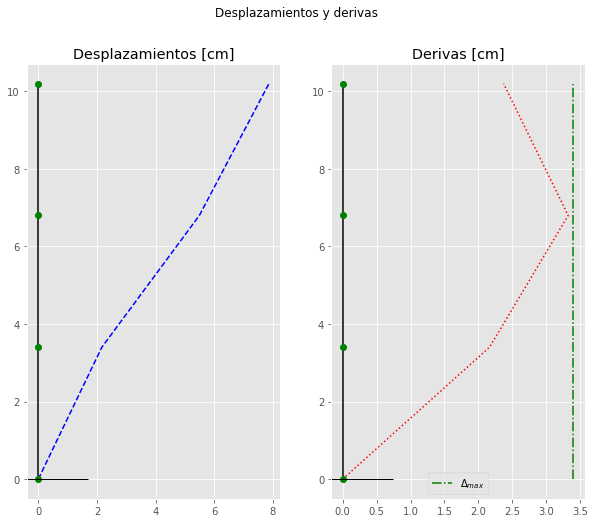

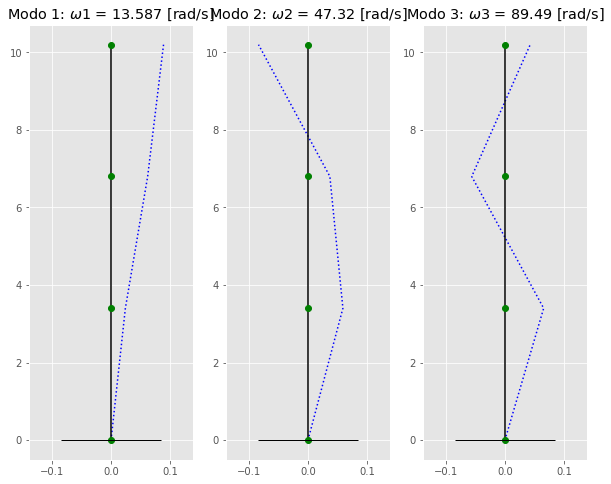

In [ ]:
# GRÁFICO DE LOS MODOS Y DESPLAZAMIENTOS
graf_Phi = np.concatenate((np.zeros((1,n_pisos)),Phi))
graf_estruct = np.insert(h_acumu,0,0)
graf_U = np.insert(U,0,0)
graf_Urel = np.insert(U_rel,0,0)

fig = plt.figure()
fig.set_size_inches(10, 8)
# fig.supylabel('Altura [m]')
fig.suptitle('Desplazamientos y derivas')
ax = fig.add_subplot(1,2,1)
ax.grid(visible=True)
ax.plot(graf_U, graf_estruct, '--b')
ax.plot(np.zeros(n_pisos+1), graf_estruct, '-k')
ax.plot(np.zeros(n_pisos+1), graf_estruct, 'og')
ax.plot(0,0,'_k', markersize=100)
ax.set_title(f"Desplazamientos [cm]")
ax = fig.add_subplot(1,2,2)
ax.grid(visible=True)
ax.plot(graf_Urel, graf_estruct, ':r')
ax.plot(np.zeros(n_pisos+1), graf_estruct, '-k')
ax.plot(np.zeros(n_pisos+1), graf_estruct, 'og')
ax.plot(np.zeros(n_pisos+1)+DeltaMAX, graf_estruct, '-.g', label=r'$\Delta_{max}$')
ax.plot(0,0,'_k', markersize=100)
ax.legend()
ax.set_title(f"Derivas [cm]")
plt.show()

fig = plt.figure()
fig.set_size_inches(10, 8)
#fig.supylabel('Altura [m]')
for i in range(n_pisos):
   ax = fig.add_subplot(1,3,1+i)
   ax.grid(visible=True)
   ax.plot(graf_Phi[:,i], graf_estruct, ':b')
   ax.plot(np.zeros(n_pisos+1), graf_estruct, '-k')
   ax.plot(np.zeros(n_pisos+1), graf_estruct, 'og')
   ax.plot(0,0,'_k', markersize=100)
   ax.set_title(f"Modo {i+1}: "+r"$\omega$"+f"{i+1} = {wwi[i].round(3)} [rad/s]")
   lim = np.max(abs(Phi))+0.05
   ax.set_xlim([-lim, lim])
plt.show()
